# MARKETPLACE LENDING CASE STUDY

## 1. ORIGINATIONS DATA CLEANING AND STRATIFICATIONS

## IMPORTING NECESSARY LIBRARIES

In [1]:
#Imports and display settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import weibull_min
import statsmodels.api as sm

%matplotlib inline

sns.set(style="whitegrid")
pd.options.display.float_format = '{:.3f}'.format

## IMPORTING LOAN DATA (orig) AND PERFORMANCE DATA (perf)

In [2]:
orig = pd.read_excel(r'C:\Users\nranc\OneDrive\Desktop\Credigy Case Study\Marketplace_Lending_Case_Study_(FRA)_-_DATA.xlsx', sheet_name=0)

In [3]:
perf = pd.read_csv(r'C:\Users\nranc\OneDrive\Desktop\Credigy Case Study\Marketplace_Lending_Case_Study_(FRA)_-_PERFORMANCE_loan-level.csv')

## QUICK SCHEMA AND COUNTS

### LOAN DATA - ORIGINATION DATA QUALITY CHECKS & STRATIFICATIONS

In [4]:
orig.head()

,Loan_ID,OriginalBalance,OriginalTerm,RiskGrade,OriginationDate,OriginationQuarter,InterestRate,OriginalMonthlyPayment,OriginationFee,FICO,PreLoanDTI,VerifiedAnnualIncome,EmploymentStatus,LoanPurpose,StatedHomeOwnership,State
0,1,4500,36,B,2016-05-02,2016Q2,0.092,143.600,202.500,763,0.205,54000,Employed,Debt Consolidation,Mortgage,TN
1,2,2500,36,B,2016-05-02,2016Q2,0.118,82.780,112.500,716,0.136,55085,Employed,Debt Consolidation,Own,MD
2,3,9000,36,A,2016-05-02,2016Q2,0.235,350.740,90.000,781,0.065,57000,Employed,Home Improvement,Own,MI
3,4,5000,36,F,2016-05-02,2016Q2,0.062,152.680,275.000,0,0.017,45000,Employed,Debt Consolidation,Mortgage,MN
4,5,10000,60,B,2016-05-04,2016Q2,0.110,217.590,550.000,787,0.158,40000,Retired,Debt Consolidation,Mortgage,IL


In [5]:
orig.info()
orig.describe (include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41559 entries, 0 to 41558
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Loan_ID                 41559 non-null  int64         
 1   OriginalBalance         41559 non-null  int64         
 2   OriginalTerm            41559 non-null  int64         
 3   RiskGrade               41559 non-null  object        
 4   OriginationDate         41559 non-null  datetime64[ns]
 5   OriginationQuarter      41559 non-null  object        
 6   InterestRate            41559 non-null  float64       
 7   OriginalMonthlyPayment  41559 non-null  float64       
 8   OriginationFee          41559 non-null  float64       
 9   FICO                    41559 non-null  int64         
 10  PreLoanDTI              41559 non-null  float64       
 11  VerifiedAnnualIncome    41559 non-null  int64         
 12  EmploymentStatus        41142 non-null  object

,Loan_ID,OriginalBalance,OriginalTerm,RiskGrade,OriginationDate,OriginationQuarter,InterestRate,OriginalMonthlyPayment,OriginationFee,FICO,PreLoanDTI,VerifiedAnnualIncome,EmploymentStatus,LoanPurpose,StatedHomeOwnership,State
count,41559.000,41559.000,41559.000,41559,41559,41559,41559.000,41559.000,41559.000,41559.000,41559.000,41559.000,41142,41559,41559,41559
unique,NaN,NaN,NaN,6,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,4,6,3,55
top,NaN,NaN,NaN,B,NaN,2019Q3,NaN,NaN,NaN,NaN,NaN,NaN,Employed,Debt Consolidation,Mortgage,CA
freq,NaN,NaN,NaN,10986,NaN,5156,NaN,NaN,NaN,NaN,NaN,NaN,35284,27525,28244,3687
mean,20780.000,21631.258,47.996,NaN,2018-11-22 09:17:11.949757952,NaN,0.135,393.802,625.433,704.287,0.136,85953.240,NaN,NaN,NaN,NaN
min,1.000,2000.000,36.000,NaN,2016-05-02 00:00:00,NaN,0.053,60.220,9.900,0.000,0.000,24000.000,NaN,NaN,NaN,NaN
25%,10390.500,8000.000,36.000,NaN,2018-03-03 00:00:00,NaN,0.096,223.230,296.305,682.000,0.078,54000.000,NaN,NaN,NaN,NaN
50%,20780.000,11500.000,36.000,NaN,2018-12-14 00:00:00,NaN,0.125,322.850,495.000,716.000,0.127,75000.000,NaN,NaN,NaN,NaN
75%,31169.500,20000.000,60.000,NaN,2019-08-21 00:00:00,NaN,0.168,505.595,880.000,755.000,0.185,103000.000,NaN,NaN,NaN,NaN
max,41559.000,100000000.000,60.000,NaN,2020-12-31 00:00:00,NaN,0.249,1420.540,2470.500,7722.000,1.470,2000000.000,NaN,NaN,NaN,NaN


In [6]:
orig['EmploymentStatus'].unique()

array(['Employed', 'Retired', 'Other', 'Self-Employed', nan], dtype=object)

#### ** Filling Null Employement Status values with new category 'Unkown.' No major impacts to data quality.

In [7]:
# 1. Convert all text in the 'State' column to uppercase
orig['EmploymentStatus'] = orig['EmploymentStatus'].fillna('Unknown')
orig['EmploymentStatus'].unique()

array(['Employed', 'Retired', 'Other', 'Self-Employed', 'Unknown'],
      dtype=object)

In [8]:
orig['State'].unique()

array(['TN', 'MD', 'MI', 'MN', 'IL', 'IN', 'NE', 'CA', 'RI', 'AZ', 'MA',
       'NM', 'PA', 'NJ', 'FL', 'VT', 'SC', 'TX', 'OH', 'AR', 'VA', 'CO',
       'GA', 'AL', 'OR', 'WA', 'MO', 'NC', 'ND', 'MS', 'NY', 'CT', 'NH',
       'LA', 'WI', 'ME', 'KS', 'OK', 'DC', 'ID', 'DE', 'KY', 'WV', 'UT',
       'WY', 'SD', 'MT', 'AK', 'IA', 'NV', 'HI', 'Ga', 'Ky', 'mo', 'Fl'],
      dtype=object)

#### ** There are 55 unique states due to differences in abbreviation. Reducing it by fixing the strings to uppercase.

In [9]:
# 1. Converting all text in the 'State' column to uppercase
orig['State'] = orig['State'].str.upper()
orig['State'].unique()
# 2. To overwrite the _-_DATA file
#orig.to_excel(r'C:\Users\nranc\OneDrive\Desktop\Credigy Case Study\Marketplace_Lending_Case_Study_(FRA)_-_DATA.xlsx'', index=False)

array(['TN', 'MD', 'MI', 'MN', 'IL', 'IN', 'NE', 'CA', 'RI', 'AZ', 'MA',
       'NM', 'PA', 'NJ', 'FL', 'VT', 'SC', 'TX', 'OH', 'AR', 'VA', 'CO',
       'GA', 'AL', 'OR', 'WA', 'MO', 'NC', 'ND', 'MS', 'NY', 'CT', 'NH',
       'LA', 'WI', 'ME', 'KS', 'OK', 'DC', 'ID', 'DE', 'KY', 'WV', 'UT',
       'WY', 'SD', 'MT', 'AK', 'IA', 'NV', 'HI'], dtype=object)

### CHECKING FOR MISSING VALUES

In [10]:
missing_summary = orig.isna().sum().sort_values(ascending=False)
missing_summary

Loan_ID                   0
OriginalBalance           0
OriginalTerm              0
RiskGrade                 0
OriginationDate           0
OriginationQuarter        0
InterestRate              0
OriginalMonthlyPayment    0
OriginationFee            0
FICO                      0
PreLoanDTI                0
VerifiedAnnualIncome      0
EmploymentStatus          0
LoanPurpose               0
StatedHomeOwnership       0
State                     0
dtype: int64

In [11]:
critical_cols = ["Loan_ID", "OriginalBalance", "OriginalTerm", "InterestRate", "OriginationDate"]
orig_missing_critical = orig[orig[critical_cols].isna().any(axis=1)]
orig_missing_critical[["Loan_ID"] + critical_cols]

,Loan_ID,Loan_ID,OriginalBalance,OriginalTerm,InterestRate,OriginationDate


#### ** No missing values in key fields (LoanID, OriginalBalance, OriginalTerm, InterestRat, OriginationDate) 
####  If there were missing values in these fields -> likely to exclude those loans from most analyses and quantify their impact

In [12]:
duplicate_ids = orig["Loan_ID"][orig["Loan_ID"].duplicated()].unique()
duplicate_ids

array([], dtype=int64)

#### ** No Duplicate Loan IDs. If there were 1) exact duplicates; I'd keep one and drop others. 2) If there were conflicting records; either exclude those Loan_IDs or choose a rule like latest origination date.

### CHECKING RANGES FOR: INTEREST RATE, TERM, DTI, VERIFIED INCOME, ORIGINAL BALANCE AND FICO

In [13]:
# Interest Rate Range
orig[["InterestRate"]].describe()

,InterestRate
count,41559.000
mean,0.135
std,0.050
min,0.053
25%,0.096
50%,0.125
75%,0.168
max,0.249


#### ** Expecting IR to be between 5% - 24%. According to the table result Min = 0.053 and Max = 0.249. IR Range is good.

In [14]:
# Term Range
orig[["OriginalTerm"]].describe()

,OriginalTerm
count,41559.000
mean,47.996
std,12.000
min,36.000
25%,36.000
50%,36.000
75%,60.000
max,60.000


#### ** Expecting Original Term to be 36 or 60 Months. According to the results Min = 36 and Max = 60. Original Term Range is good.

In [15]:
#DTI Range
orig[["PreLoanDTI"]].describe()

,PreLoanDTI
count,41559.000
mean,0.136
std,0.079
min,0.000
25%,0.078
50%,0.127
75%,0.185
max,1.470


#### ** Expecting DTI be between 0 and approximately 60%. The min is 0 and the max is 147%. This raises data issue concerns.

In [16]:
#Verified Income Range
orig[["VerifiedAnnualIncome"]].describe()

,VerifiedAnnualIncome
count,41559.000
mean,85953.240
std,52130.272
min,24000.000
25%,54000.000
50%,75000.000
75%,103000.000
max,2000000.000


#### ** Expecting range between 10K and 500K. Results show Min is 24K, which is sound. However, the maximum is $2M, which doesn't seem right.

In [17]:
# Original Balance Range
orig[["OriginalBalance"]].describe()

,OriginalBalance
count,41559.000
mean,21631.258
std,849531.185
min,2000.000
25%,8000.000
50%,11500.000
75%,20000.000
max,100000000.000


#### ** According to the results Max Original Balance = $100M. There is a data issue with Original Balance

In [18]:
# FICO Range
orig[["FICO"]].describe()

,FICO
count,41559.000
mean,704.287
std,428.132
min,0.000
25%,682.000
50%,716.000
75%,755.000
max,7722.000


#### ** Expecting FICO Range to be between 300 - 850. According to the table result Min = 0 and Max = 7722. There's a data issue in FICO column.

### CREATING THE LIST OF LOAN IDs W/ DATA ISSUES

In [19]:
# Creating an empty dictionary called issues, which will store loan IDs that have some data issue.
issues = {}

#Data Integrity Filters: Out of Range 1. Fico, 2. Rate, 3. Term
issues["fico_out_of_range"] = orig[(orig["FICO"] < 300) | (orig["FICO"] > 850)] #FICO less than 300 OR FICO greater than 850
issues["rate_out_of_range"] = orig[(orig["InterestRate"] < 0.05) | (orig["InterestRate"] > 0.26)] #Interest Rates < 5% OR > 26%
issues["term_invalid"] = orig[~orig["OriginalTerm"].isin([36, 60])] #Isolating loans having an unconventional loan term other than 36 or 60 Months
issues["origbal_out_of_range"] = orig[orig["OriginalBalance"] > 50000]
issues["dti_out_of_range"] = orig[(orig["PreLoanDTI"] < 0) | (orig["PreLoanDTI"] > 0.60)]
issues["verif_income_incorrect"] = orig[(orig["VerifiedAnnualIncome"] < 10000) | (orig["VerifiedAnnualIncome"] > 500000)]

# Combine all issue dataframes into one, adding a column for the issue type
df_all_issues = pd.concat(
    {name: df[["Loan_ID", "FICO", "InterestRate", "OriginalTerm","OriginalBalance","PreLoanDTI","VerifiedAnnualIncome"]]
     for name, df in issues.items()},
    names=["Issue_Type"]
).reset_index(level=0)

# *** List of ALL TROUBLED LOAN IDs ***
df_all_issues = df_all_issues.reset_index(drop=True)
df_all_issues


,Issue_Type,Loan_ID,FICO,InterestRate,OriginalTerm,OriginalBalance,PreLoanDTI,VerifiedAnnualIncome
0,fico_out_of_range,4,0,0.062,36,5000,0.017,45000
1,fico_out_of_range,33,0,0.131,60,30000,0.141,65000
2,fico_out_of_range,59,0,0.102,36,10000,0.144,80000
3,fico_out_of_range,65,0,0.183,60,10000,0.183,101000
4,fico_out_of_range,69,0,0.112,36,4500,0.016,80000
...,...,...,...,...,...,...,...,...
2590,verif_income_incorrect,36872,775,0.074,36,45000,0.038,620000
2591,verif_income_incorrect,37798,645,0.107,36,35000,0.064,832000
2592,verif_income_incorrect,38414,765,0.074,36,35000,0.045,525000
2593,verif_income_incorrect,40564,793,0.101,60,45000,0.035,600000


In [20]:
# All the Issue Types.
df_all_issues['Issue_Type'].unique()

array(['fico_out_of_range', 'origbal_out_of_range', 'dti_out_of_range',
       'verif_income_incorrect'], dtype=object)

### BREAKDOWN OF ISSUE TYPES

In [21]:
# FICO vs. Original Balance vs. DTI vs. Verified Income
fico_series = issues["fico_out_of_range"]["FICO"]

fico_0_count = (fico_series == 0).sum()
fico_7722_count = (fico_series == 7722).sum()

ob_issues = len(issues["origbal_out_of_range"])
dti_issues = len(issues["dti_out_of_range"])
vi_issues = len(issues["verif_income_incorrect"])


print(f"""
FICO_0:    {fico_0_count:,} ({fico_0_count / len(fico_series):.2%})
FICO_7722: {fico_7722_count:,} ({fico_7722_count / len(fico_series):.2%})

Other Issues Tracked:
- Original Balance: {ob_issues}
- DTI:              {dti_issues}
- Verified Income:  {vi_issues}
- FICO:             {len(fico_series)}
- Total Issues:     {len(fico_series) + ob_issues + dti_issues + vi_issues}
""")


FICO_0:    2,433 (95.00%)
FICO_7722: 128 (5.00%)

Other Issues Tracked:
- Original Balance: 3
- DTI:              2
- Verified Income:  29
- FICO:             2561
- Total Issues:     2595



#### ** Observations of the Data Issues.
Out of the initial 41,559 records, 2,561 observations (6.16%) exhibited out-of-range FICO scores consisting of 0 (2433 count or 95%) and 7722 (128 count or 5%). In addition, 3 IDs had Original Balance of \\$1M, 2 had DTI greater than 60%, and 29 had Annual Income greater than $500K. Because valid FICO scores strictly range between 300 and 850, these extreme entries represent system-generated placeholder codes, unscoreable applicants, or data transmission errors rather than actual credit risk metrics.For the purposes of this case study, these records were removed via listwise exclusion rather than altered through capping or imputation. Imputing values for these records would introduce artificial noise and distort the empirical relationship between credit scores and performance outcomes. Given the low volume of excluded data, the remaining sample of 38,965 records retains robust statistical power. Consequently, the scope of this analysis is explicitly bounded to the scoreable applicant population.

DTI Range Check:  
Pre‑Loan DTI values were validated to fall within an economically reasonable range of 0% to 60%. Values above 60% are inconsistent with marketplace lending underwriting standards and were removed as non‑economic outliers.

Verified Income Range Check:  
Verified Annual Income was validated to fall within \\$10,000 to $500,000. Values outside this range are inconsistent with borrower affordability and typical platform limits. These records were removed due to unrecoverable data corruption.

Treatment:  
All loans with invalid DTI or income values were excluded from the analytical dataset. These fields cannot be reliably imputed because they directly affect affordability, DTI, and risk grade assignment.

## QUANTIFY IMPACT OF PROBLEMATIC LOAN IDs ON PORTFOLIO-LEVEL WEIGHTED AVERAGES

### FUNCTION TO COMPUTE WEIGHTED AVERAGES (WA) OF METRICS

In [22]:
def weighted_average(df, value, weight="OriginalBalance"):
    return (df[value] * df[weight]).sum() / df[weight].sum()

### CREATING THE ORIGINATION LOAN DATA WITHOUT PROBLEM LOAN IDs

In [23]:
problem_ids = pd.concat(issues.values())["Loan_ID"].unique()
orig_clean = orig[~orig["Loan_ID"].isin(problem_ids)]

In [24]:
impact = pd.DataFrame({
    "Metric": ["WA_FICO", "WA_InterestRate", "WA_PreLoanDTI", "TotalBalance", "AvgBalance"],
    "Raw": [
        weighted_average(orig, "FICO"),
        weighted_average(orig, "InterestRate"),
        weighted_average(orig, "PreLoanDTI"),
        orig["OriginalBalance"].sum(),
        orig["OriginalBalance"].mean()
    ],
    "Clean": [
        weighted_average(orig_clean, "FICO"),
        weighted_average(orig_clean, "InterestRate"),
        weighted_average(orig_clean, "PreLoanDTI"),
        orig_clean["OriginalBalance"].sum(),
        orig_clean["OriginalBalance"].mean()
    ]
})

impact["Change"] = impact["Clean"] - impact["Raw"]
impact

,Metric,Raw,Clean,Change
0,WA_FICO,716.205,733.494,17.289
1,WA_InterestRate,0.138,0.126,-0.013
2,WA_PreLoanDTI,0.134,0.126,-0.007
3,TotalBalance,898973433.000,561841336.000,-337132097.000
4,AvgBalance,21631.258,14419.128,-7212.129


#### ** Data cleaning observation:
The data cleaning had a material and directional impact on the portfolio. Removing corrupted 100M loans and invalid FICO values increased WA FICO by 17 points, reduced WA Interest Rate by 130 bps, and lowered WA DTI. Total portfolio balance decreased by $337M, confirming that the raw dataset was dominated by non‑economic outliers.

The cleaned dataset provides a materially more accurate and economically realistic representation of the platform’s credit quality and should be used for all downstream analysis.

Because WA FICO and Total Original Balance changed materially, 

- performance curves will look better after cleaning.

- cohort segmentation will be more accurate.

- curve projections will be more reliable.

- credit story for the platform becomes stronger.

## 2. STRATIFICATIONS

### WEIGHTED AVERAGE FICO BY ORIGINATION YEAR

In [25]:
orig_clean = orig_clean.reset_index(drop=True)
orig_clean["OriginationDate"] = pd.to_datetime(orig_clean["OriginationDate"])
orig_clean["OriginationYear"] = orig_clean["OriginationDate"].dt.year

In [26]:
wa_fico_by_year = (
    orig_clean.groupby("OriginationYear")
        .apply(lambda g: weighted_average(g, "FICO", "OriginalBalance"), include_groups=False)
        .rename("WA_FICO")
        .reset_index()
)
wa_fico_by_year

,OriginationYear,WA_FICO
0,2016,743.416
1,2017,740.020
2,2018,738.963
3,2019,724.047
4,2020,739.708


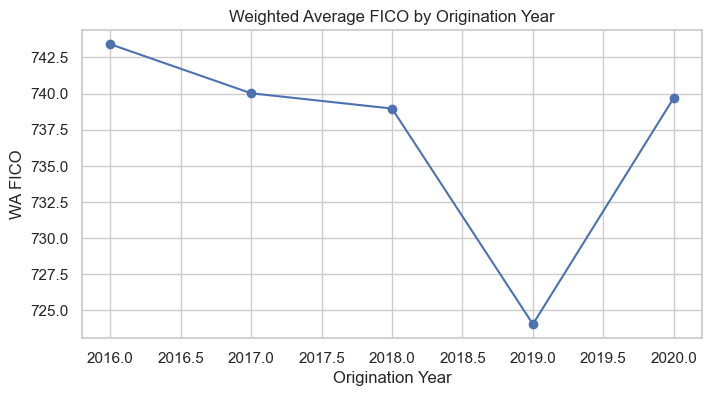

In [27]:
plt.figure(figsize=(8,4))
plt.plot(wa_fico_by_year["OriginationYear"], wa_fico_by_year["WA_FICO"], marker="o")
plt.title("Weighted Average FICO by Origination Year")
plt.xlabel("Origination Year")
plt.ylabel("WA FICO")
plt.grid(True)
plt.show()

### WA INTEREST RATE BY RISK GRADE

In [28]:
wa_rate_by_grade = (
    orig_clean.groupby("RiskGrade")
        .apply(lambda g: weighted_average(g, "InterestRate", "OriginalBalance"), include_groups=False)
        .rename("WA_InterestRate")
        .reset_index()
)
wa_rate_by_grade.sort_values("RiskGrade")

,RiskGrade,WA_InterestRate
0,A,0.084
1,B,0.108
2,C,0.140
3,D,0.171
4,E,0.204
5,F,0.231


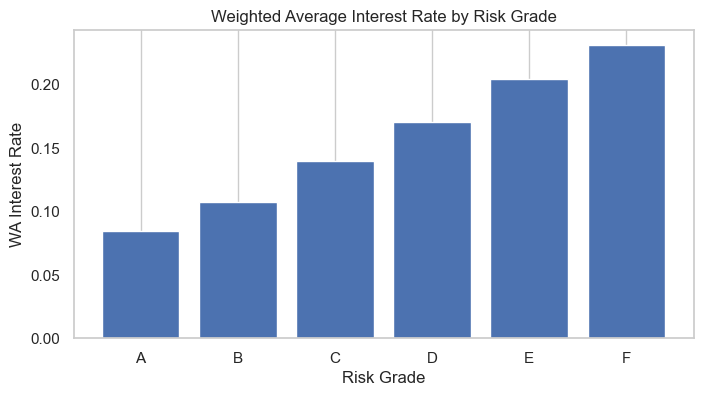

In [29]:
plt.figure(figsize=(8,4))
plt.bar(wa_rate_by_grade["RiskGrade"], wa_rate_by_grade["WA_InterestRate"])
plt.title("Weighted Average Interest Rate by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("WA Interest Rate")
plt.grid(axis="y")
plt.show()

### % OF ORIGINAL BALANCE FROM 100 LARGEST LOANS

In [30]:
orig_sorted = orig_clean.sort_values("OriginalBalance", ascending=False)
top_100 = orig_sorted.head(100)

total_balance = orig_clean["OriginalBalance"].sum()
top_100_balance = top_100["OriginalBalance"].sum()

pct_top_100 = top_100_balance / total_balance
print(f"""
Top 100 Balance:   {top_100_balance:,}
Total Balance:   {total_balance:,}

% of Orig Balance from 100 Largest Loans: ({top_100_balance / total_balance:.2%})
""")


Top 100 Balance:   4,319,103
Total Balance:   561,841,336

% of Orig Balance from 100 Largest Loans: (0.77%)



### ** Observation:
The top 100 loans represent only 0.77% of total portfolio balance, indicating exceptionally low concentration risk and a highly granular portfolio structure that supports stable, predictable performance.

### EXPOSURE BY STATE (% OF ORIGINAL BALANCE)

In [31]:

state_exposure = (orig_clean.groupby("State")["OriginalBalance"].sum().reset_index())
state_exposure["Total_OrigBal"] = orig_clean["OriginalBalance"].sum()
state_exposure["Pct_of_Portfolio"] = (state_exposure["OriginalBalance"] /  orig_clean["OriginalBalance"].sum())*100
state_exposure = state_exposure.sort_values("Pct_of_Portfolio", ascending = False)

In [32]:
state_exposure.head(11)

,State,OriginalBalance,Total_OrigBal,Pct_of_Portfolio
4,CA,55859925,561841336,9.942
43,TX,44458477,561841336,7.913
22,MI,43117053,561841336,7.674
9,FL,39716331,561841336,7.069
34,NY,24883678,561841336,4.429
10,GA,23161976,561841336,4.123
35,OH,23142277,561841336,4.119
38,PA,22101455,561841336,3.934
14,IL,21098142,561841336,3.755
31,NJ,17974782,561841336,3.199


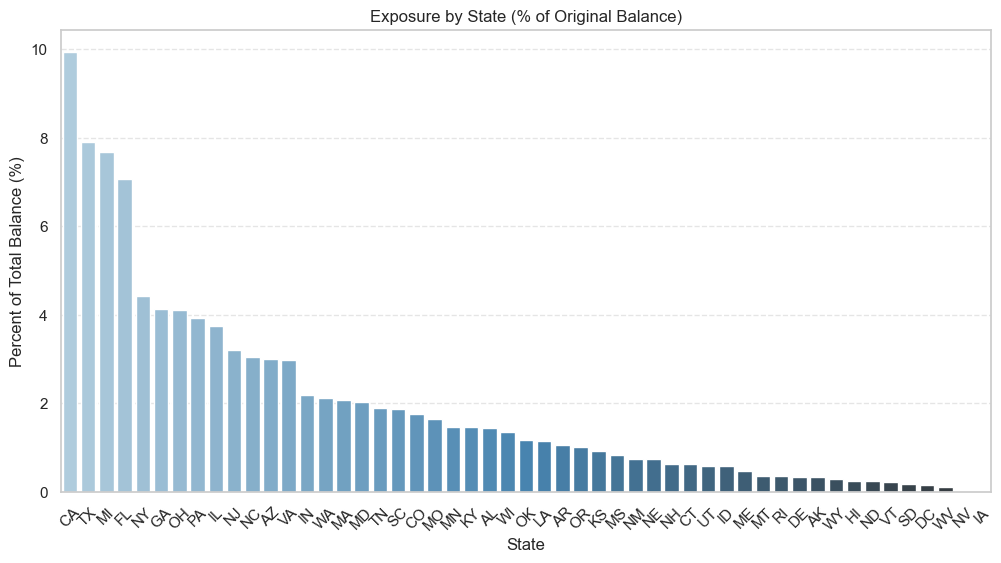

In [33]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=state_exposure,
    x="State",
    y="Pct_of_Portfolio",
    hue="State",
    palette="Blues_d",
    legend=False
)
plt.title("Exposure by State (% of Original Balance)")
plt.ylabel("Percent of Total Balance (%)")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

#### ** Observation
The portfolio demonstrates healthy geographic diversification with a predictable concentration in large population centers.
No single state poses outsized systemic risk, but the top five states should be included in enhanced monitoring due to their combined exposure.

### AVERAGE MONTHLY PAYMENTS BY RISK GRADE AND ORIGINATION YEAR

In [34]:
avg_pmt_grade_year = (
    orig_clean.groupby(["RiskGrade", "OriginationYear"])["OriginalMonthlyPayment"]
        .mean()
        .reset_index()
)
avg_pmt_grade_year_pivot = avg_pmt_grade_year.pivot(index="RiskGrade", columns="OriginationYear", values="OriginalMonthlyPayment")
avg_pmt_grade_year_pivot

OriginationYear,2016,2017,2018,2019,2020
RiskGrade,,,,,
A,457.405,461.786,451.084,408.769,411.628
B,482.267,474.927,455.799,409.563,427.150
C,471.178,474.603,459.206,420.288,432.543
D,392.152,377.377,363.927,361.121,369.480
E,269.320,281.360,277.814,249.795,252.086
F,251.089,232.628,226.139,228.921,214.590


### ** Observation
Average monthly payments decline from 2016 to 2020 across all risk grades, reflecting a shift toward longer terms and affordability‑driven loan structures. The clear and consistent payment hierarchy across grades demonstrates disciplined risk‑based pricing and stable underwriting practices

### 3- VS 5-YEAR MIX AT RISK GRADE LEVEL (% OF BALANCE)

In [35]:
# Calculate total balance per group
group_sums = orig_clean.groupby(["RiskGrade", "OriginalTerm"])["OriginalBalance"].sum().reset_index()

# Divide each row's balance by the sum total of its respective RiskGrade
group_sums["Pct_of_Balance"] = (group_sums["OriginalBalance"] / group_sums.groupby("RiskGrade")["OriginalBalance"].transform("sum"))*100

term_mix = group_sums[["RiskGrade", "OriginalTerm", "Pct_of_Balance"]]
term_mix

,RiskGrade,OriginalTerm,Pct_of_Balance
0,A,36,53.066
1,A,60,46.934
2,B,36,40.585
3,B,60,59.415
4,C,36,33.481
5,C,60,66.519
6,D,36,30.442
7,D,60,69.558
8,E,36,59.835
9,E,60,40.165


<Figure size 1000x600 with 0 Axes>

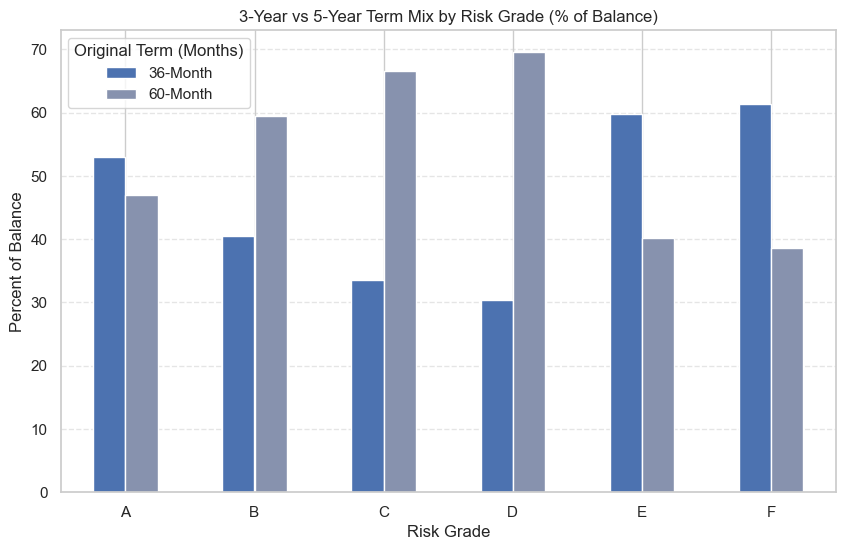

In [36]:
df = term_mix

# Pivot for plotting
pivot_df = df.pivot(index="RiskGrade", columns="OriginalTerm", values="Pct_of_Balance")
pivot_df = pivot_df[[36, 60]]  # ensure order

# Plot
plt.figure(figsize=(10,6))
pivot_df.plot(kind="bar", figsize=(10,6), color=["#4C72B0", "#8792AE"])

plt.title("3-Year vs 5-Year Term Mix by Risk Grade (% of Balance)")
plt.xlabel("Risk Grade")
plt.ylabel("Percent of Balance")
plt.xticks(rotation=0)
plt.legend(title="Original Term (Months)", labels=["36-Month", "60-Month"])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

#### ** Observation:

The term mix shows disciplined underwriting. Prime borrowers (A-47%,B-59%,C-67%) lean toward longer term (5-Year) to support affordability, while higher‑risk borrowers (E-60%,F-61%) are concentrated in shorter terms (3-Year) to limit lifetime loss exposure. This is a positive risk‑management signal because the platform is not stretching high‑risk borrowers into long‑duration loans.

### WEIGHTED AVERAGE POST-LOAN DTI BY SATED HOME OWNERSHIP

In [37]:
orig_clean["PostLoanDTI_approx"] = orig_clean["PreLoanDTI"] + (
    (orig_clean["OriginalMonthlyPayment"] * 12) / orig_clean["VerifiedAnnualIncome"]
)

wa_post_dti_by_home = (
    orig_clean.groupby("StatedHomeOwnership")
              .apply(lambda g: weighted_average(g, "PostLoanDTI_approx", "OriginalBalance"),include_groups=False)
              .rename("WA_PostLoanDTI")
              .reset_index()
)
wa_post_dti_by_home

,StatedHomeOwnership,WA_PostLoanDTI
0,Mortgage,0.200
1,Own,0.193
2,Rent,0.196


#### ** Observation:

Weighted Average Post‑Loan DTI has a narrow spread across all home‑ownership categories, ranging from 19.3% to 20.0%, indicating strong affordability discipline and consistent underwriting standards.

# 3. PERFORMANCE CURVES

## QUICK SCHEMA AND DATA QUALITY CHECKS

In [38]:
perf.head()

,Loan_ID,Origination_Quarter,MonthsOnBook,BOM_UPB,EOM_UPB,INT_PMT,TOTAL_PRIN_PMT,TOTAL_PREPAYMENT_AMT,CHARGE_OFF_AMT
0,1400,2017Q1,0,NaN,14000.000,0.000,0.000,0.000,0.000
1,1401,2017Q1,0,NaN,20000.000,0.000,0.000,0.000,0.000
2,1402,2017Q1,0,NaN,25000.000,0.000,0.000,0.000,0.000
3,1403,2017Q1,0,NaN,20000.000,0.000,0.000,0.000,0.000
4,1404,2017Q1,0,NaN,20000.000,0.000,0.000,0.000,0.000


In [39]:
perf.info()
perf.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759404 entries, 0 to 759403
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Loan_ID               759404 non-null  int64  
 1   Origination_Quarter   759404 non-null  object 
 2   MonthsOnBook          759404 non-null  int64  
 3   BOM_UPB               719247 non-null  float64
 4   EOM_UPB               759404 non-null  float64
 5   INT_PMT               759404 non-null  float64
 6   TOTAL_PRIN_PMT        759404 non-null  float64
 7   TOTAL_PREPAYMENT_AMT  759404 non-null  float64
 8   CHARGE_OFF_AMT        759404 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 52.1+ MB


,Loan_ID,Origination_Quarter,MonthsOnBook,BOM_UPB,EOM_UPB,INT_PMT,TOTAL_PRIN_PMT,TOTAL_PREPAYMENT_AMT,CHARGE_OFF_AMT
count,759404.000,759404,759404.000,719247.000,759404.000,759404.000,759404.000,759404.000,759404.000
unique,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2017Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,84243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,18250.362,NaN,11.747,11247.139,10912.527,113.281,475.103,217.809,26.337
std,10787.490,NaN,9.056,7829.892,7914.831,80.934,1892.622,1870.821,619.928
min,1400.000,NaN,0.000,61.030,0.000,0.000,0.000,0.000,0.000
25%,9043.000,NaN,4.000,5508.050,5167.460,51.650,121.620,0.000,0.000
50%,17012.000,NaN,10.000,8935.070,8687.290,99.610,211.500,0.000,0.000
75%,26839.000,NaN,17.000,15358.150,15006.760,155.790,350.380,0.000,0.000


In [40]:
#Missing Values for Performance Dataset
orig_clean["Loan_ID"] = orig_clean["Loan_ID"].astype(int)
perf["Loan_ID"] = perf["Loan_ID"].astype(int)

display(perf.isna().sum().sort_values(ascending=False).head(20))
# 1. Negative or invalid MonthsOnBook
neg_mob = perf.loc[perf['MonthsOnBook'] < 0, ['Loan_ID','MonthsOnBook']]
print("Negative MonthsOnBook rows:", len(neg_mob))
if not neg_mob.empty:
    display(neg_mob.head())

# 2. Negative BOM_UPB or EOM_UPB and missing counts
for col in ['BOM_UPB','EOM_UPB']:
    neg = perf.loc[perf[col] < 0, ['Loan_ID','MonthsOnBook',col]]
    n_neg = len(neg)
    n_null = perf[col].isna().sum()
    print(f"{col}: {n_neg} negative, {n_null} missing")
    if n_neg:
        display(neg.head())

# 3. Duplicate loan-month rows
dup_rows = perf[perf.duplicated(subset=['Loan_ID','MonthsOnBook'], keep=False)]
print("Duplicate loan-month rows:", len(dup_rows))
if not dup_rows.empty:
    display(dup_rows.head())

# 4. Join integrity between orig and perf
missing_in_perf = set(orig_clean['Loan_ID']) - set(perf['Loan_ID'])
missing_in_orig = set(perf['Loan_ID']) - set(orig_clean['Loan_ID'])
print("Loans in orig not in perf:", len(missing_in_perf))
print("Loans in perf not in orig:", len(missing_in_orig))
print("Unique IDs in Orig:", orig_clean['Loan_ID'].nunique())
print("Unique IDs in Perf:", perf['Loan_ID'].nunique())

BOM_UPB                 40157
Loan_ID                     0
Origination_Quarter         0
MonthsOnBook                0
EOM_UPB                     0
INT_PMT                     0
TOTAL_PRIN_PMT              0
TOTAL_PREPAYMENT_AMT        0
CHARGE_OFF_AMT              0
dtype: int64

Negative MonthsOnBook rows: 0
BOM_UPB: 0 negative, 40157 missing
EOM_UPB: 0 negative, 0 missing
Duplicate loan-month rows: 0
Loans in orig not in perf: 1261
Loans in perf not in orig: 2453
Unique IDs in Orig: 38965
Unique IDs in Perf: 40157


Performance curves are calculated only on loans that appear in both the cleaned origination dataset and the performance dataset. Loans missing from the performance file have no time‑series data and therefore cannot contribute to cumulative default or prepayment calculations. An inner join ensures that static pools, cohort balances, and performance curves are based on a consistent and analytically valid universe.

In [41]:
# Inner join = correct analysis universe
perf_aligned = perf.merge(
    orig_clean,
    on="Loan_ID",
    how="inner"
)

# Rename for clarity
perf_aligned = perf_aligned.rename(columns={
    "CHARGE_OFF_AMT": "Default_Amt",
    "TOTAL_PREPAYMENT_AMT": "Prepay_Amt"
})

# Also create aligned origination dataset if necessary
#orig_aligned = orig_clean[orig_clean["Loan_ID"].isin(perf_aligned["Loan_ID"])]

In [42]:
perf_aligned.describe(include='all')

,Loan_ID,Origination_Quarter,MonthsOnBook,BOM_UPB,EOM_UPB,INT_PMT,TOTAL_PRIN_PMT,Prepay_Amt,Default_Amt,OriginalBalance,...,OriginationFee,FICO,PreLoanDTI,VerifiedAnnualIncome,EmploymentStatus,LoanPurpose,StatedHomeOwnership,State,OriginationYear,PostLoanDTI_approx
count,711059.000,711059,711059.000,673355.000,711059.000,711059.000,711059.000,711059.000,711059.000,711059.000,...,711059.000,711059.000,711059.000,711059.000,711059,711059,711059,711059,711059.000,711059.000
unique,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5,6,3,51,NaN,NaN
top,NaN,2018Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Employed,Debt Consolidation,Mortgage,CA,NaN,NaN
freq,NaN,79877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,603806,475271,490067,63126,NaN,NaN
mean,18395.839,NaN,11.707,11264.788,10929.980,113.361,474.923,217.922,26.641,14277.019,...,636.392,724.893,0.137,84498.224,NaN,NaN,NaN,NaN,2018.226,0.199
min,1400.000,NaN,0.000,61.030,0.000,0.000,0.000,0.000,0.000,2000.000,...,9.900,640.000,0.000,24000.000,NaN,NaN,NaN,NaN,2017.000,0.006
25%,9292.000,NaN,4.000,5524.990,5191.235,51.560,121.860,0.000,0.000,8000.000,...,300.000,688.000,0.079,53000.000,NaN,NaN,NaN,NaN,2018.000,0.138
50%,17185.000,NaN,10.000,8956.010,8716.020,99.600,211.760,0.000,0.000,11000.000,...,498.000,720.000,0.129,73500.000,NaN,NaN,NaN,NaN,2018.000,0.190
75%,26965.000,NaN,17.000,15373.305,15027.480,156.000,349.980,0.000,0.000,20000.000,...,896.400,757.000,0.187,101739.500,NaN,NaN,NaN,NaN,2019.000,0.256
max,41559.000,NaN,47.000,45000.000,45000.000,447.410,43813.830,43213.790,38291.520,45000.000,...,2470.500,850.000,0.391,500000.000,NaN,NaN,NaN,NaN,2020.000,0.400


In [43]:
print("Unique IDs in Perf:", perf_aligned['Loan_ID'].nunique())

Unique IDs in Perf: 37704


### MONTHLY PERFORMANCE TABLE

In [44]:
# Aggregate by Months On Book (all vintages combined)
agg = (
    perf_aligned
    .groupby("MonthsOnBook")
    .agg({
        "Default_Amt": "sum",
        "Prepay_Amt": "sum",
        "OriginalBalance": "sum"
    })
    .reset_index()
)

# Static pool original balance (cohort total at MOB=0)
orig_balance_perf = agg["OriginalBalance"].iloc[0]

### MONTHLY DEFAULT AND PREPAYMENT RATES

In [45]:
agg["MonthlyDefaultRate"] = agg["Default_Amt"] / orig_balance_perf
agg["MonthlyPrepayRate"]  = agg["Prepay_Amt"]  / orig_balance_perf

In [46]:
agg.head()

,MonthsOnBook,Default_Amt,Prepay_Amt,OriginalBalance,MonthlyDefaultRate,MonthlyPrepayRate
0,0,0.000,0.000,543300447,0.000,0.000
1,1,0.000,8659650.220,543300447,0.000,0.016
2,2,25129.600,9822312.990,534495057,0.000,0.018
3,3,18053.720,10253468.070,514874121,0.000,0.019
4,4,59955.420,11391660.750,504066069,0.000,0.021


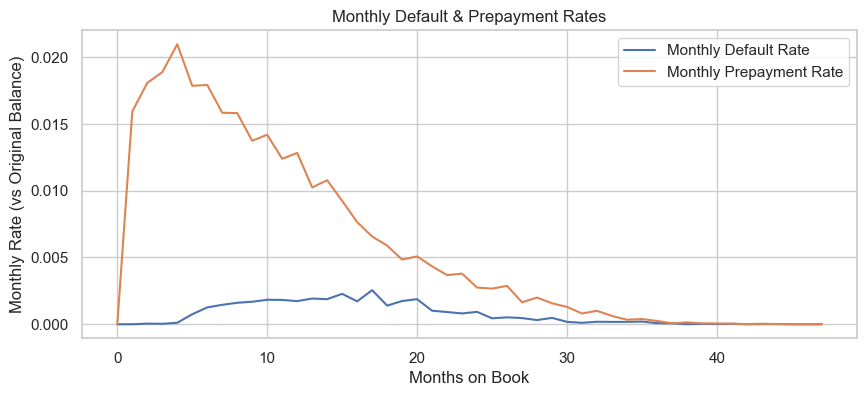

In [47]:
plt.figure(figsize=(10,4))
plt.plot(agg["MonthsOnBook"], agg["MonthlyDefaultRate"], label="Monthly Default Rate")
plt.plot(agg["MonthsOnBook"], agg["MonthlyPrepayRate"], label="Monthly Prepayment Rate")
plt.xlabel("Months on Book")
plt.ylabel("Monthly Rate (vs Original Balance)")
plt.title("Monthly Default & Prepayment Rates")
plt.legend()
plt.grid(True)
plt.show()

### CUMULATIVE DEFAULT & PREPAYMENT RATES

In [48]:
agg["CumDefaultRate"] = agg["MonthlyDefaultRate"].cumsum()
agg["CumPrepayRate"]  = agg["MonthlyPrepayRate"].cumsum()

In [49]:
agg.head()

,MonthsOnBook,Default_Amt,Prepay_Amt,OriginalBalance,MonthlyDefaultRate,MonthlyPrepayRate,CumDefaultRate,CumPrepayRate
0,0,0.000,0.000,543300447,0.000,0.000,0.000,0.000
1,1,0.000,8659650.220,543300447,0.000,0.016,0.000,0.016
2,2,25129.600,9822312.990,534495057,0.000,0.018,0.000,0.034
3,3,18053.720,10253468.070,514874121,0.000,0.019,0.000,0.053
4,4,59955.420,11391660.750,504066069,0.000,0.021,0.000,0.074


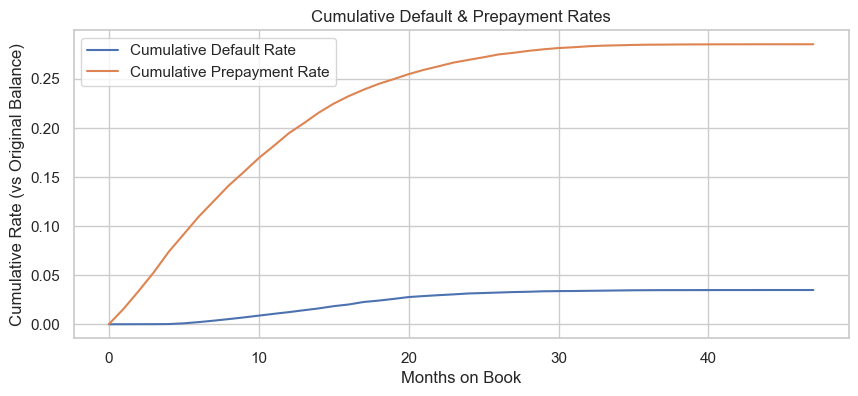

In [50]:
plt.figure(figsize=(10,4))
plt.plot(agg["MonthsOnBook"], agg["CumDefaultRate"], label="Cumulative Default Rate")
plt.plot(agg["MonthsOnBook"], agg["CumPrepayRate"], label="Cumulative Prepayment Rate")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Rate (vs Original Balance)")
plt.title("Cumulative Default & Prepayment Rates")
plt.legend()
plt.grid(True)
plt.show()

## 4. CURVE PROJECTION (TO 60 MOB)

In [51]:
max_mob = agg["MonthsOnBook"].max()
horizon = 60

proj = agg.copy()

last_def = agg.loc[agg["MonthsOnBook"] == max_mob, "MonthlyDefaultRate"].values[0]
last_prep = agg.loc[agg["MonthsOnBook"] == max_mob, "MonthlyPrepayRate"].values[0]

future = pd.DataFrame({"MonthsOnBook": range(max_mob+1, horizon+1)})
steps = horizon - max_mob

future["MonthlyDefaultRate"] = last_def * (1 - (future["MonthsOnBook"] - max_mob) / steps)
future["MonthlyPrepayRate"]  = last_prep * (1 - (future["MonthsOnBook"] - max_mob) / steps)

future["MonthlyDefaultRate"] = future["MonthlyDefaultRate"].clip(lower=0)
future["MonthlyPrepayRate"]  = future["MonthlyPrepayRate"].clip(lower=0)

proj = pd.concat([proj, future], ignore_index=True)
proj = proj.sort_values("MonthsOnBook")

proj["CumDefaultRate"] = proj["MonthlyDefaultRate"].cumsum()
proj["CumPrepayRate"]  = proj["MonthlyPrepayRate"].cumsum()


In [52]:
max_mob

47

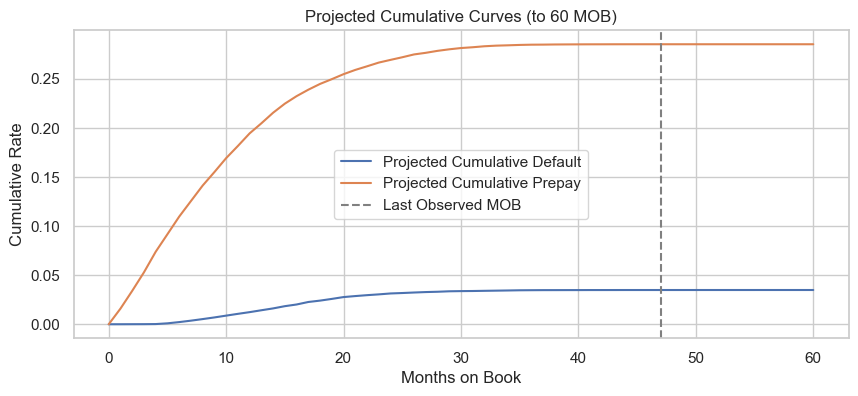

In [53]:
plt.figure(figsize=(10,4))
plt.plot(proj["MonthsOnBook"], proj["CumDefaultRate"], label="Projected Cumulative Default")
plt.plot(proj["MonthsOnBook"], proj["CumPrepayRate"], label="Projected Cumulative Prepay")
plt.axvline(max_mob, color="gray", linestyle="--", label="Last Observed MOB")
plt.title("Projected Cumulative Curves (to 60 MOB)")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Rate")
plt.legend()
plt.grid(True)
plt.show()

## 5. COHORT ANALYSIS

### CREATING FICO BANDS AND TERM BANDS COHORTS

In [54]:
# Create FICO bands
perf_aligned["FICO_Band"] = pd.cut(
    perf_aligned["FICO"],
    bins=[640, 680, 720, 760, 900],
    labels=["640-679", "680-719", "720-759", "760+"],
    include_lowest=True
)

# Create Term bands
perf_aligned["TermBand"] = perf_aligned["OriginalTerm"].astype(str) + "m"

### CREATING ORIGINATION YEAR COHORT

In [55]:
perf_aligned["OriginationYear"] = perf_aligned["Origination_Quarter"].str[:4].astype(int)

### DEFINING COHORT DIMENSIONS

In [56]:
cohort_cols = ["OriginationYear", "FICO_Band", "TermBand"]

In [57]:
cohort_perf = (
    perf_aligned
    .groupby(cohort_cols + ["MonthsOnBook"], observed = True)
    .agg({
        "Default_Amt": "sum",
        "Prepay_Amt": "sum",
        "OriginalBalance": "sum"
    })
    .reset_index()
)

#### COMPUTE MARGINAL MONTHLY RATES RELATIVE TO THE ORIGINAL POOL BALANCE

In [58]:
cohort_perf["MonthlyDefaultRate"] = cohort_perf["Default_Amt"] / cohort_perf["OriginalBalance"]
cohort_perf["MonthlyPrepayRate"]  = cohort_perf["Prepay_Amt"]  / cohort_perf["OriginalBalance"]

#### ISOLATE EACH COHORT AND CALCULATE THE RUNNING CUMULATIVE SUMS

In [59]:
cohort_perf["CumDefaultRate"] = cohort_perf.groupby(cohort_cols, observed=True)["MonthlyDefaultRate"].cumsum()
cohort_perf["CumPrepayRate"]  = cohort_perf.groupby(cohort_cols, observed=True)["MonthlyPrepayRate"].cumsum()

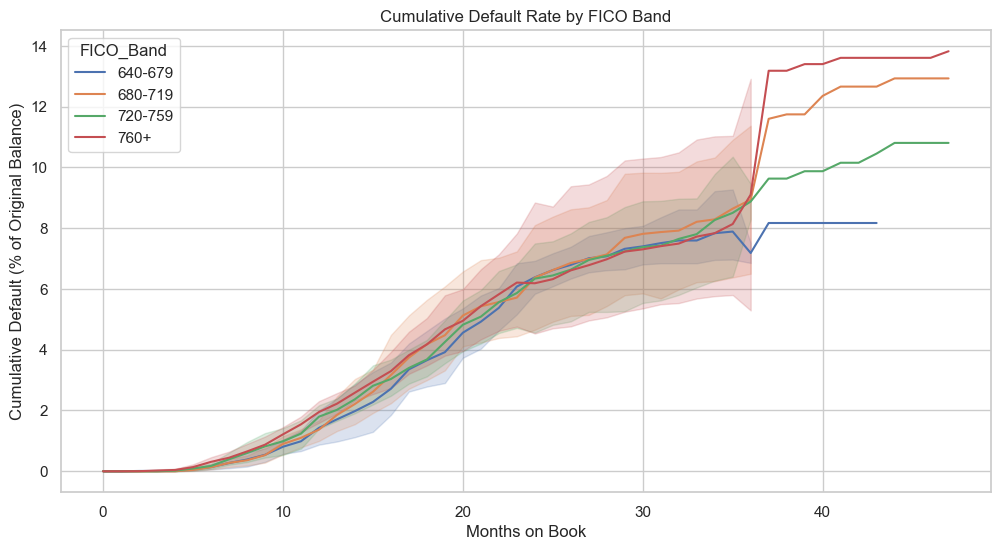

In [60]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=cohort_perf,
    x="MonthsOnBook",
    y=cohort_perf["CumDefaultRate"]*100,
    hue="FICO_Band"
)
plt.title("Cumulative Default Rate by FICO Band")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Default (% of Original Balance)")
plt.grid(True)
plt.show()

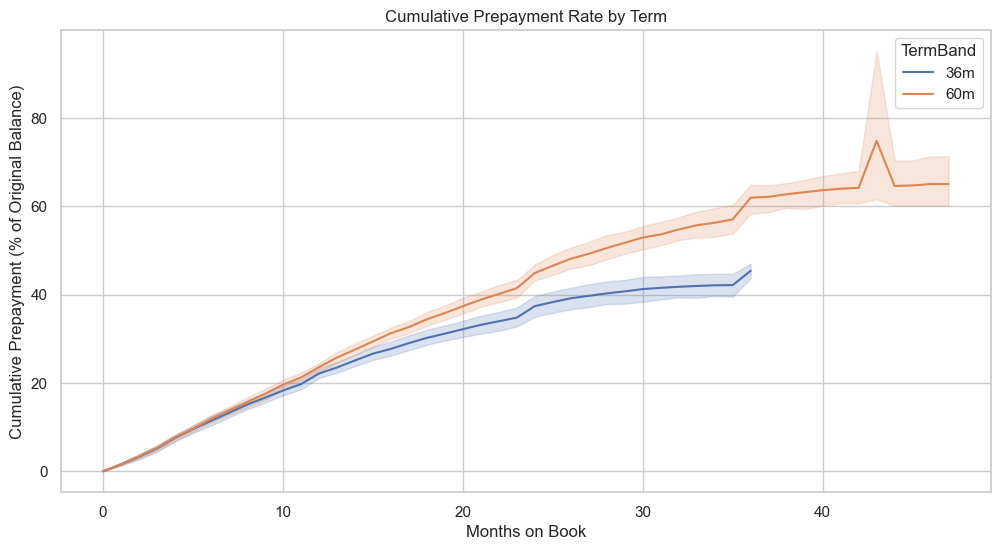

In [61]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=cohort_perf,
    x="MonthsOnBook",
    y=cohort_perf["CumPrepayRate"]*100,
    hue="TermBand"
)
plt.title("Cumulative Prepayment Rate by Term")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Prepayment (% of Original Balance)")
plt.grid(True)
plt.show()

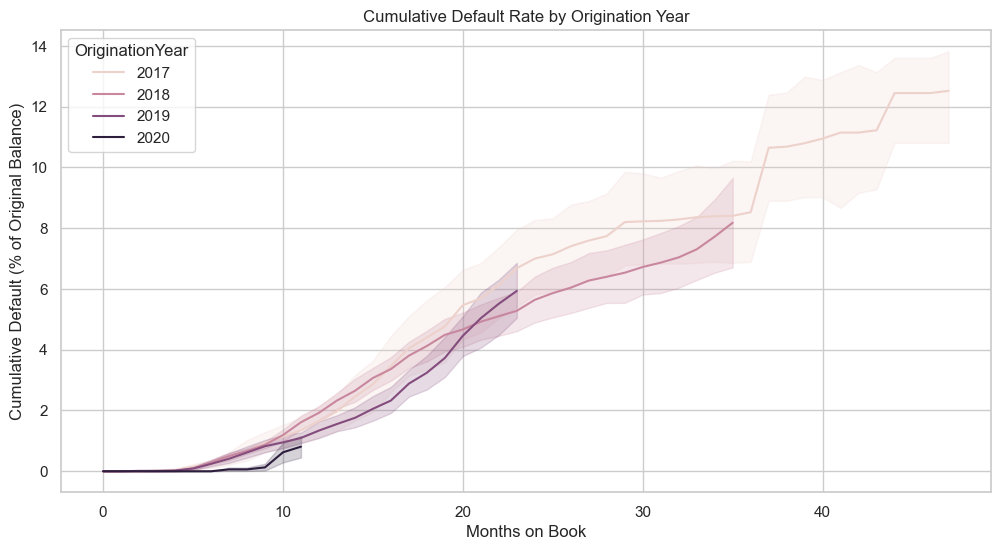

In [62]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=cohort_perf,
    x="MonthsOnBook",
    y=cohort_perf["CumDefaultRate"]*100,
    hue="OriginationYear"
)
plt.title("Cumulative Default Rate by Origination Year")
plt.xlabel("Months on Book")
plt.ylabel("Cumulative Default (% of Original Balance)")
plt.grid(True)
plt.show()

In [63]:
final_mob = cohort_perf["MonthsOnBook"].max()

cohort_ranking = (
    cohort_perf[cohort_perf["MonthsOnBook"] == final_mob]
    .sort_values("CumDefaultRate")
    .reset_index(drop=True)
)

In [64]:
cohort_ranking

,OriginationYear,FICO_Band,TermBand,MonthsOnBook,Default_Amt,Prepay_Amt,OriginalBalance,MonthlyDefaultRate,MonthlyPrepayRate,CumDefaultRate,CumPrepayRate
0,2017,720-759,60m,47,0.000,0.000,658700,0.000,0.000,0.108,0.637
1,2017,680-719,60m,47,0.000,0.000,284000,0.000,0.000,0.129,0.713
2,2017,760+,60m,47,1362.490,0.000,628000,0.002,0.000,0.138,0.602


## 6. COVID-19 VINTAGE TREATMENT

#### COVID‑19 Vintage Treatment

2020 vintages were affected by:
- Payment deferrals
- Forbearance programs
- Stimulus-driven prepayments
- Temporary delinquency suppression

**Recommended Approach**
- Include 2020 vintages but tag them as COVID-affected.
- Use 2017–2019 vintages for base-case curve calibration.
- Use 2020 vintages as a stress scenario reference.
- Clearly disclose COVID impact in performance commentary.